# Dataset Structure & Quality Validation
## Adapted for `vegetable_Dataset/` Layout

This notebook validates the **raw dataset** before running any feature extraction.
It checks:

1. **Folder structure** — all expected `Fresh<Veg>` / `Rotten<Veg>` folders exist
2. **Image counts** — enough samples per class for reliable SVM training
3. **Class balance** — fresh vs rotten ratio per vegetable
4. **Image integrity** — sample images are readable and not corrupt
5. **Feature separability (quick)** — HSV-based features visually separable?
6. **SVM margin feasibility** — can a linear SVM separate fresh from rotten on simple features?

Run this **before** `extract_dataset_features.py`.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

## Configuration

Set the path to your `vegetable_Dataset/` folder and the list of target vegetables.
These must match `utils.py → TARGET_VEGETABLES`.

In [2]:
# Path to the raw dataset (adjust if needed)
BASE_PATH = "../vegetable_Dataset"

# Must match TARGET_VEGETABLES in utils.py
TARGET_VEGETABLES = {"apple", "banana", "capsicum", "cucumber", "potato"}

# Expected folder names (case-insensitive prefix matching)
EXPECTED_FOLDERS = [
    "FreshApple", "RottenApple",
    "FreshBanana", "RottenBanana",
    "FreshCapsicum", "RottenCapsicum",
    "FreshCucumber", "RottenCucumber",
    "FreshPotato", "RottenPotato",
]

print(f"Dataset path : {os.path.abspath(BASE_PATH)}")
print(f"Exists       : {os.path.exists(BASE_PATH)}")

Dataset path : /home/midori/Desktop/mini-project/vegetable_Dataset
Exists       : True


## Check 1 — Folder Structure

Verify all expected `Fresh<Veg>` / `Rotten<Veg>` folders exist inside `vegetable_Dataset/`.

In [3]:
print("=" * 50)
print("CHECK 1 — FOLDER STRUCTURE")
print("=" * 50)

all_present = True

for folder in EXPECTED_FOLDERS:
    path = os.path.join(BASE_PATH, folder)
    if os.path.isdir(path):
        print(f"  PASS  {folder}")
    else:
        print(f"  FAIL  {folder}  ← MISSING")
        all_present = False

print()
if all_present:
    print("RESULT: All expected folders found.")
else:
    print("RESULT: Some folders are missing. Fix before running feature extraction.")

CHECK 1 — FOLDER STRUCTURE
  PASS  FreshApple
  PASS  RottenApple
  PASS  FreshBanana
  PASS  RottenBanana
  PASS  FreshCapsicum
  PASS  RottenCapsicum
  PASS  FreshCucumber
  PASS  RottenCucumber
  PASS  FreshPotato
  PASS  RottenPotato

RESULT: All expected folders found.


## Check 2 — Image Counts per Class

Count images in each folder.

- **≥ 300 fresh images per vegetable** → SVM training is reliable
- **150–299** → borderline, results may vary
- **< 150** → too few, SVM will likely overfit

In [4]:
def parse_folder(folder_name):
    """Parse 'FreshApple' → ('apple', 'fresh'), 'RottenBanana' → ('banana', 'rotten')."""
    name = folder_name.lower()
    if name.startswith("fresh"):
        return name[len("fresh"):], "fresh"
    if name.startswith("rotten"):
        return name[len("rotten"):], "rotten"
    return None, None

IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

records = {}   # records[veg][freshness] = count
all_paths = []  # (path, veg, freshness)

if os.path.exists(BASE_PATH):
    for entry in sorted(os.scandir(BASE_PATH), key=lambda e: e.name):
        if not entry.is_dir():
            continue
        veg, freshness = parse_folder(entry.name)
        if veg not in TARGET_VEGETABLES:
            continue
        if veg not in records:
            records[veg] = {"fresh": 0, "rotten": 0}
        for f in os.scandir(entry.path):
            if not f.is_file():
                continue
            ext = os.path.splitext(f.name)[1].lower()
            if ext not in IMAGE_EXTS:
                continue
            records[veg][freshness] += 1
            all_paths.append((f.path, veg, freshness))

print("=" * 55)
print("CHECK 2 — IMAGE COUNTS")
print("=" * 55)
print(f"{'Vegetable':<12}  {'Fresh':>8}  {'Rotten':>8}  {'Total':>7}  Result")
print("-" * 55)

total_images = 0
for veg in sorted(records):
    f = records[veg]["fresh"]
    r = records[veg]["rotten"]
    t = f + r
    total_images += t
    verdict = "PASS" if f >= 300 else ("WEAK" if f >= 150 else "FAIL")
    print(f"{veg:<12}  {f:>8}  {r:>8}  {t:>7}  {verdict}")

print("-" * 55)
print(f"{'TOTAL':<12}  {'':>8}  {'':>8}  {total_images:>7}")

CHECK 2 — IMAGE COUNTS
Vegetable        Fresh    Rotten    Total  Result
-------------------------------------------------------
apple             1949      2530     4479  PASS
banana            2104      2593     4697  PASS
capsicum           933       155     1088  PASS
cucumber           435       474      909  PASS
potato             653       816     1469  PASS
-------------------------------------------------------
TOTAL                               12642


## Check 3 — Class Balance

Ideal fresh/rotten ratio is 0.5 – 2.0.
The SVM uses `class_weight='balanced'` to handle imbalance,
but extreme imbalance (ratio > 5 or < 0.2) will still hurt performance.

In [5]:
print("=" * 50)
print("CHECK 3 — CLASS BALANCE (fresh / rotten ratio)")
print("=" * 50)

for veg in sorted(records):
    f = records[veg]["fresh"]
    r = records[veg]["rotten"]
    ratio = f / (r + 1e-6)

    if 0.5 <= ratio <= 2.0:
        verdict = "PASS"
    elif 0.2 <= ratio <= 5.0:
        verdict = "WEAK"
    else:
        verdict = "FAIL"

    print(f"  {veg:<12}  ratio={ratio:.2f}  {verdict}")

print()
print("Note: SVM uses class_weight='balanced' — moderate imbalance is handled.")
print("      Extreme imbalance (ratio < 0.2 or > 5) should be corrected.")

CHECK 3 — CLASS BALANCE (fresh / rotten ratio)
  apple         ratio=0.77  PASS
  banana        ratio=0.81  PASS
  capsicum      ratio=6.02  FAIL
  cucumber      ratio=0.92  PASS
  potato        ratio=0.80  PASS

Note: SVM uses class_weight='balanced' — moderate imbalance is handled.
      Extreme imbalance (ratio < 0.2 or > 5) should be corrected.


## Check 4 — Image Integrity

Sample up to 100 images across all vegetable types and verify they are
readable (not corrupt, not zero-size).

In [6]:
print("=" * 50)
print("CHECK 4 — IMAGE INTEGRITY (sample 100)")
print("=" * 50)

rng = np.random.default_rng(42)
sample_paths = [p for p, _, _ in all_paths]

if len(sample_paths) > 100:
    sample_paths = list(rng.choice(sample_paths, 100, replace=False))

failed = []
ok = 0

for p in sample_paths:
    img = cv2.imread(p)
    if img is None or img.size == 0:
        failed.append(p)
    else:
        ok += 1

print(f"  Checked : {len(sample_paths)} images")
print(f"  OK      : {ok}")
print(f"  Failed  : {len(failed)}")

if failed:
    print()
    print("  Failed files:")
    for p in failed[:10]:
        print(f"    {p}")
    verdict = "FAIL" if len(failed) > 5 else "WEAK"
else:
    verdict = "PASS"

print(f"\nRESULT: {verdict}")

CHECK 4 — IMAGE INTEGRITY (sample 100)
  Checked : 100 images
  OK      : 100
  Failed  : 0

RESULT: PASS


## Check 5 — Feature Separability (HSV Quick Features)

Extract simple 6-dim HSV mean+std features from a sample of images
and check PCA separation between fresh and rotten.

This is a **quick sanity check** on raw images before running the full
1312-dim EfficientNetB0 + handcrafted pipeline.

If even HSV features separate the classes → the dataset has a clear
visual signal and the full pipeline will work well.

In [7]:
print("Extracting HSV features from a sample of images...")

# Sample up to 500 images
sample = all_paths
if len(sample) > 500:
    idx = rng.choice(len(sample), 500, replace=False)
    sample = [all_paths[i] for i in idx]

def extract_hsv_features(path_list, size=(128, 128)):
    """Extract 6-dim HSV mean+std features (fast, no deep model)."""
    feats, vegs, labels = [], [], []
    for (p, veg, freshness) in path_list:
        img = cv2.imread(p)
        if img is None:
            continue
        img = cv2.resize(img, size)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
        mean = hsv.mean(axis=(0, 1))
        std  = hsv.std(axis=(0, 1))
        feats.append(np.concatenate([mean, std]))
        vegs.append(veg)
        labels.append(1 if freshness == "fresh" else 0)
    return np.array(feats), np.array(vegs), np.array(labels)

X_hsv, vegs_sample, y_sample = extract_hsv_features(sample)
print(f"Extracted {len(X_hsv)} feature vectors (6-dim HSV).")

Extracting HSV features from a sample of images...
Extracted 500 feature vectors (6-dim HSV).


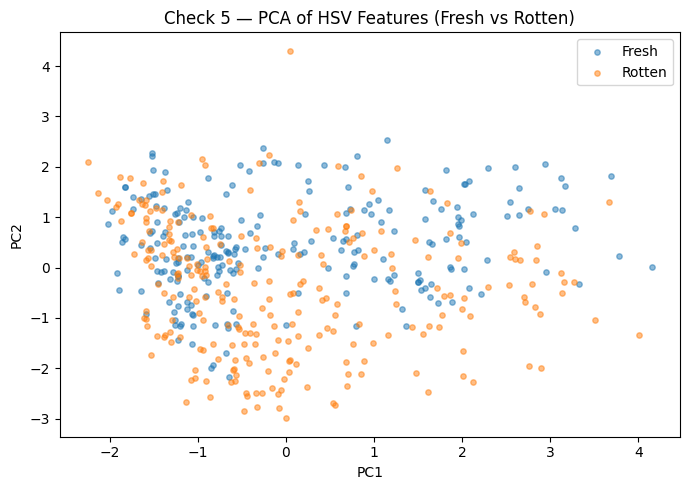

VERDICT: Inspect the plot.
  PASS → Two visible clusters (even loose separation is good)
  FAIL → Fully mixed. Raw colour features carry no signal.


In [8]:
scaler_hsv = StandardScaler()
X_hsv_s = scaler_hsv.fit_transform(X_hsv)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_hsv_s)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[y_sample == 1, 0], X_pca[y_sample == 1, 1],
            label='Fresh', alpha=0.5, s=15)
plt.scatter(X_pca[y_sample == 0, 0], X_pca[y_sample == 0, 1],
            label='Rotten', alpha=0.5, s=15)
plt.title("Check 5 — PCA of HSV Features (Fresh vs Rotten)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

print("VERDICT: Inspect the plot.")
print("  PASS → Two visible clusters (even loose separation is good)")
print("  FAIL → Fully mixed. Raw colour features carry no signal.")

## Check 6 — SVM Margin Feasibility (HSV Quick Features)

Train a quick linear SVM on the HSV features and check whether it can
separate fresh from rotten above chance (AUC > 0.6).

This is a **lower bound** — your full pipeline uses 1312-dim features
from EfficientNetB0 which will always be much stronger.

If even the HSV SVM fails (AUC < 0.55) → the dataset likely has
labelling errors or severe image quality issues.

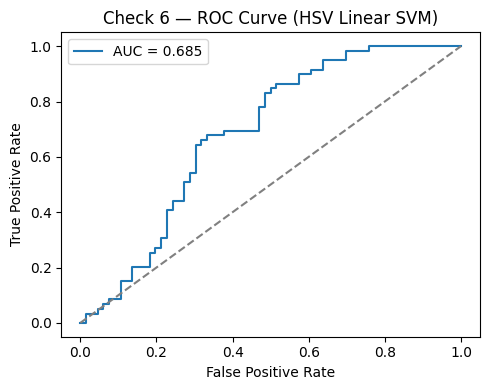

AUC = 0.6852
RESULT: WEAK — Moderate signal. Full pipeline should be much better.


In [9]:
if len(np.unique(y_sample)) < 2:
    print("Not enough class diversity in sample to run SVM check.")
else:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_hsv_s, y_sample, test_size=0.25, stratify=y_sample, random_state=42
    )

    svm_q = SVC(kernel="linear", probability=True)
    svm_q.fit(X_tr, y_tr)

    probs = svm_q.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.title("Check 6 — ROC Curve (HSV Linear SVM)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"AUC = {roc_auc:.4f}")

    if roc_auc >= 0.75:
        verdict = "PASS — Strong signal even on HSV alone."
    elif roc_auc >= 0.60:
        verdict = "WEAK — Moderate signal. Full pipeline should be much better."
    else:
        verdict = "FAIL — Very weak signal. Check dataset labels and image quality."

    print(f"RESULT: {verdict}")

## Check 7 — Per-Vegetable Visualisation

Plot sample images from each vegetable type (fresh and rotten) to visually
verify that labels are correct and images look as expected.

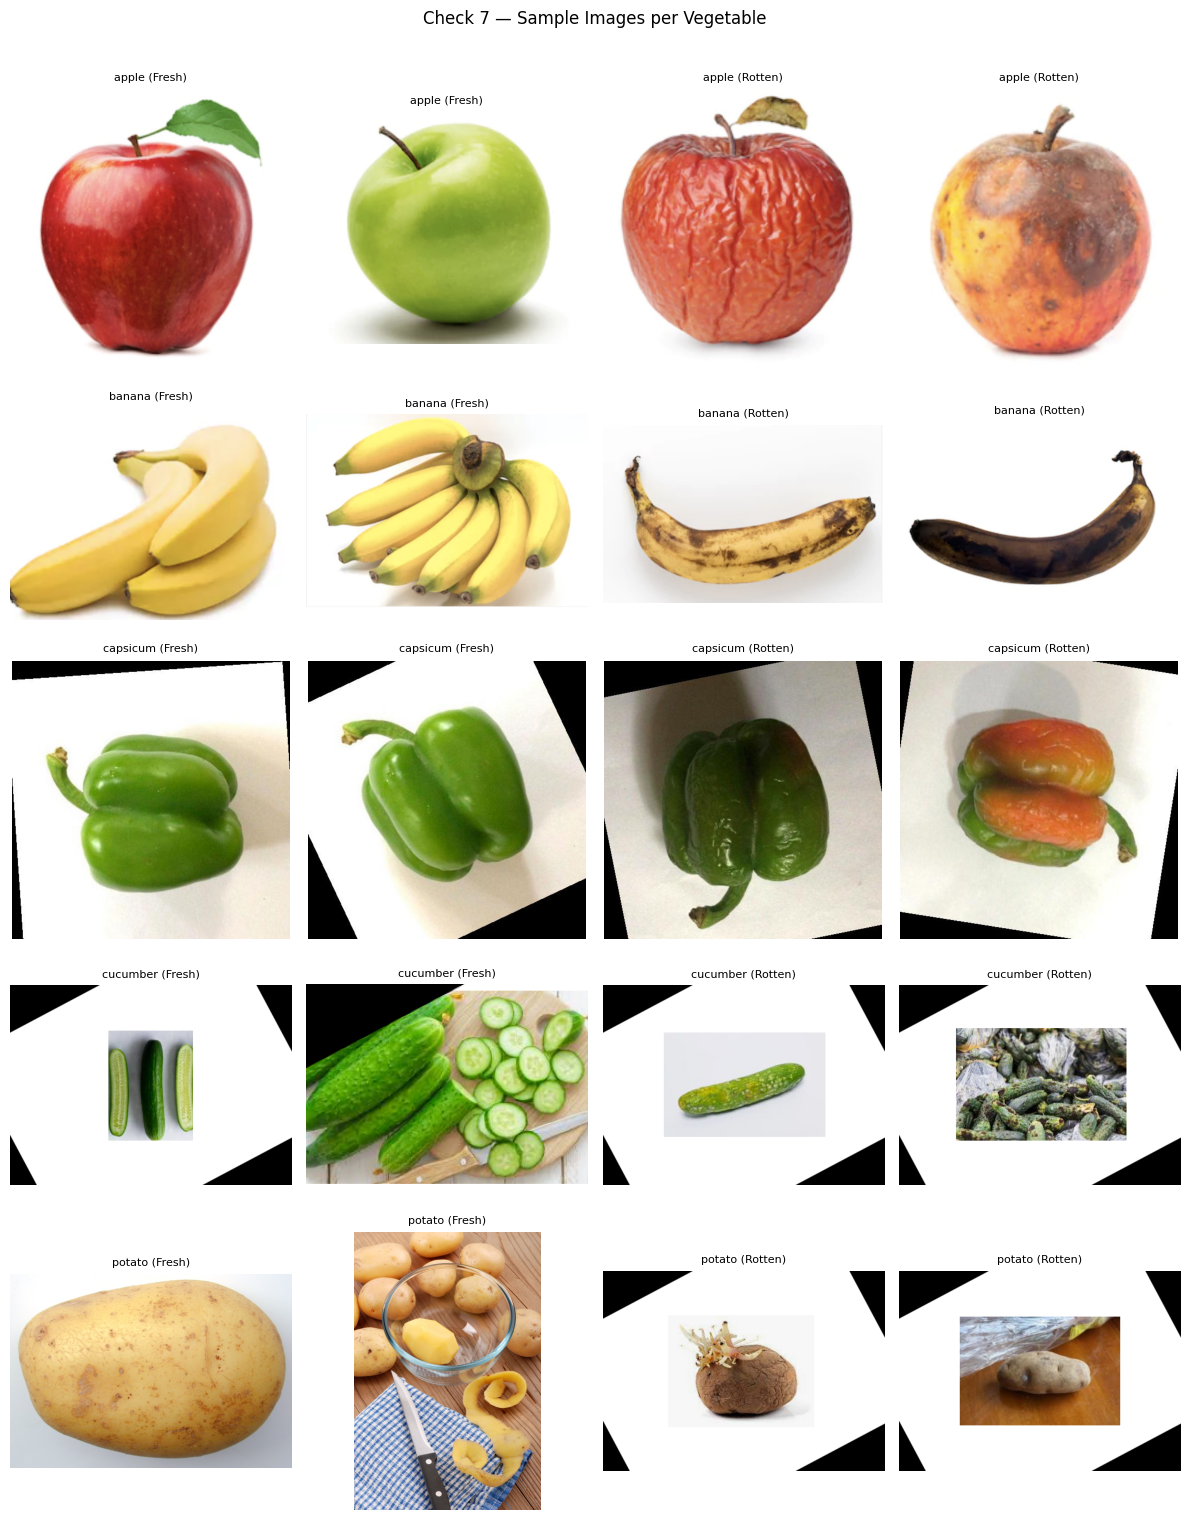

In [10]:
# Show 2 fresh + 2 rotten per vegetable
from collections import defaultdict

by_class = defaultdict(lambda: defaultdict(list))
for (p, veg, freshness) in all_paths:
    by_class[veg][freshness].append(p)

n_vegs = len(by_class)
n_cols = 4  # 2 fresh + 2 rotten

fig, axes = plt.subplots(n_vegs, n_cols, figsize=(12, 3 * n_vegs))
if n_vegs == 1:
    axes = [axes]

for row_idx, veg in enumerate(sorted(by_class.keys())):
    fresh_paths  = by_class[veg]["fresh"][:2]
    rotten_paths = by_class[veg]["rotten"][:2]

    for col_idx, (p, label) in enumerate(
        [(fp, "Fresh") for fp in fresh_paths] +
        [(rp, "Rotten") for rp in rotten_paths]
    ):
        ax = axes[row_idx][col_idx]
        img = cv2.imread(p)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
        ax.set_title(f"{veg} ({label})", fontsize=8)
        ax.axis("off")

plt.suptitle("Check 7 — Sample Images per Vegetable", y=1.01)
plt.tight_layout()
plt.show()

## Final Summary

In [11]:
print("=" * 60)
print("DATASET VALIDATION SUMMARY")
print("=" * 60)
print()
print("Check 1 — Folder structure   : See output above")
print("Check 2 — Image counts       : See table above (PASS = >= 300 fresh per veg)")
print("Check 3 — Class balance      : See output above (PASS = ratio 0.5–2.0)")
print("Check 4 — Image integrity    : See output above")
print("Check 5 — PCA separability   : Inspect plot")
print(f"Check 6 — HSV SVM AUC       : {roc_auc:.4f}  ({'PASS' if roc_auc >= 0.75 else 'WEAK' if roc_auc >= 0.60 else 'FAIL'})")
print("Check 7 — Sample images      : Inspect visually")
print()
print("If 3+ checks fail → fix the dataset before running feature extraction.")
print("If all pass → run:  python src/extract_dataset_features.py")

DATASET VALIDATION SUMMARY

Check 1 — Folder structure   : See output above
Check 2 — Image counts       : See table above (PASS = >= 300 fresh per veg)
Check 3 — Class balance      : See output above (PASS = ratio 0.5–2.0)
Check 4 — Image integrity    : See output above
Check 5 — PCA separability   : Inspect plot
Check 6 — HSV SVM AUC       : 0.6852  (WEAK)
Check 7 — Sample images      : Inspect visually

If 3+ checks fail → fix the dataset before running feature extraction.
If all pass → run:  python src/extract_dataset_features.py
